# ER 图随机基准：多噪声类型对比

随机生成 ER 图，对比以下算法在三种噪声类型下的表现：

- **cd_A_noepoch_0.2** (λ=0.2)：坐标下降（非 epoch），via `coordinate_descent.coordinate0`
- **cd_A_noepoch_0.5** (λ=0.5)：坐标下降（非 epoch），via `coordinate_descent.coordinate0`
- **GOLEM-EV**：等方差假设 GOLEM，via `golemMain/src/golem.py`
- **GOLEM-NV**：非等方差假设 GOLEM，via `golemMain/src/golem.py`
- **FGES**：Fast Greedy Equivalence Search，via `pytetrad`（需 JDK 21+）
- **NOTEARS**：连续松弛 + 增广拉格朗日，via `gcastle`

噪声类型：
- **Gaussian-EV** (`gaussian_ev`)
- **Exponential** (`exponential`)
- **Gumbel** (`gumbel`)

每种噪声类型独立运行，结果分别可视化。

In [2]:
# 1) 环境与导入
import os
import sys
import time
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 仓库根目录 ────────────────────────────────────────────────────────────────
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate


print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)

# ── 核心依赖 ──────────────────────────────────────────────────────────────────
from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset

# ── cd_A (non-epoch) ──────────────────────────────────────────────────────────
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A_noepoch

# ── NOTEARS (gcastle) ─────────────────────────────────────────────────────────
NOTEARS_IMPORT_ERROR = None
try:
    logging.disable(logging.INFO)
    from castle.algorithms import Notears as _Notears
    logging.disable(logging.NOTSET)
    HAS_NOTEARS = True
    print('NOTEARS   : OK')
except Exception as _e:
    logging.disable(logging.NOTSET)
    HAS_NOTEARS = False
    NOTEARS_IMPORT_ERROR = _e
    print('NOTEARS unavailable:', _e)

# ── FGES (pytetrad, requires JDK 21+) ────────────────────────────────────────
FGES_IMPORT_ERROR = None
try:
    import fges_compat as _ts
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _ts.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_FGES = True
    print('FGES      : OK')
except Exception as _e:
    HAS_FGES = False
    FGES_IMPORT_ERROR = _e
    print('FGES unavailable:', _e)

# ── GOLEM ─────────────────────────────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = os.path.join(repo_root, 'golemMain', 'src')
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e
    print('GOLEM unavailable:', _e)

# ── CPDAG-SHD backend (optional) ─────────────────────────────────────────────
try:
    _tb = os.path.join(repo_root, 'toolbox')
    if _tb not in sys.path:
        sys.path.append(_tb)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable (fallback):', _e)

Python   : 3.10.11
Repo root: c:\Users\super\DAG
NOTEARS   : OK
FGES      : OK
GOLEM     : OK
CPDAG-SHD backend unavailable (fallback): No module named 'GPUtil'


In [3]:
# 2) 辅助函数

def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est  = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff    = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est  = np.asarray(G_est,  dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def fges_matrix_to_adj(df_result) -> np.ndarray:
    """pytetrad get_graph_to_matrix() -> 0/1 adjacency (ARROW=2, TAIL=3)."""
    mat = df_result.values
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def _make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est, noise_type):
    mec  = int(is_in_markov_equiv_class(G_true, G_est))
    shd  = shd_score(G_true, G_est)
    cshd = cpdag_shd_score(G_true, G_est)
    return {
        'd': d, 'n_samples': n, 'trial_id': trial_id, 'seed': seed,
        'noise_type': noise_type,
        'algorithm': alg,
        'mec_match': mec,
        'shd': shd,
        'cpdag_shd': cshd,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est':  int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    return (
        df.groupby(['algorithm', 'noise_type', 'd', 'n_samples'], as_index=False)
        .agg(
            mec_match_mean   = ('mec_match',   'mean'),
            shd_mean         = ('shd',         'mean'),
            cpdag_shd_mean   = ('cpdag_shd',   'mean'),
            runtime_sec_mean = ('runtime_sec', 'mean'),
            trials           = ('trial_id',    'count'),
        )
    )


# 各算法 cell 将结果追加到这个全局列表
_ALL_ROWS: list = []
_SKIP_LOGS: list = []

print('辅助函数已定义。')

辅助函数已定义。


In [15]:
# 3) 实验配置
CFG = {
    # ── ER 图参数 ────────────────────────────────────────────────────────────
    'trials':       3,            # 每组 (d, n, noise) 重复次数
    'seed':         42,
    'd_list':       [20, 30], # 节点数
    'n_list':       [5000], # 样本量
    'degree':       2.0,          # ER 图期望度
    'noise_types':  ['gaussian_ev', 'exponential', 'gumbel'],
    'b_scale':      1.0,

    # ── 通用 ──────────────────────────────────────────────────────────────
    'threshold':    0.05,

    # ── cd_A_noepoch 参数 ─────────────────────────────────────────────────
    'T_noepoch':      100000,           # 坐标下降步数上限

    # ── NOTEARS ───────────────────────────────────────────────────────────
    'notears_lambda1':    0.1,
    'notears_loss_type':  'l2',
    'notears_threshold':  0.3,

    # ── FGES ──────────────────────────────────────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── GOLEM ─────────────────────────────────────────────────────────────
    'golem_num_iter':      100000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1_ev':    2e-2,
    'golem_lambda1_nv':    2e-3,
    'golem_lambda2':       5.0,

    # ── 输出 ──────────────────────────────────────────────────────────────
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag':     'er_noise_benchmark',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

ALGORITHM_ORDER = [
    'cd_A_noepoch_0.2',
    'cd_A_noepoch_0.5',
    'golem_ev',
    'golem_nv',
    'fges',
    'notears',
]

NOISE_LABELS = {
    'gaussian_ev': 'Gaussian-EV',
    'exponential': 'Exponential',
    'gumbel':      'Gumbel',
}

print('配置完成。')
print(f"  d_list      : {CFG['d_list']}")
print(f"  n_list      : {CFG['n_list']}")
print(f"  noise_types : {CFG['noise_types']}")
print(f"  trials      : {CFG['trials']}")
print(f'  算法列表 ({len(ALGORITHM_ORDER)} 个):')
for _a in ALGORITHM_ORDER:
    print(f'    {_a}')

配置完成。
  d_list      : [20, 30]
  n_list      : [5000]
  noise_types : ['gaussian_ev', 'exponential', 'gumbel']
  trials      : 3
  算法列表 (6 个):
    cd_A_noepoch_0.2
    cd_A_noepoch_0.5
    golem_ev
    golem_nv
    fges
    notears


In [5]:
# 4) 通用 ER 图 trial 生成器（支持多噪声类型）

def _iter_trials(cfg: dict):
    """生成器：依次产出 (noise_type, d, n, trial_id, seed, X, S, G_true)。"""
    rng = np.random.default_rng(cfg['seed'])
    for noise_type in cfg['noise_types']:
        for d in cfg['d_list']:
            for n in cfg['n_list']:
                seeds = rng.integers(0, 10**9, size=cfg['trials'])
                for trial_idx, seed in enumerate(seeds, start=1):
                    dataset = SyntheticDataset(
                        n=n, d=d,
                        graph_type='ER',
                        degree=cfg['degree'],
                        noise_type=noise_type,
                        B_scale=cfg['b_scale'],
                        seed=int(seed),
                    )
                    X      = dataset.X
                    S      = X.T @ X / X.shape[0]
                    G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
                    yield noise_type, d, n, trial_idx, int(seed), X, S, G_true


print('ER trial 生成器已定义。')

ER trial 生成器已定义。


In [6]:
# 5) cd_A_noepoch_0.2  (lambda = 0.2)
# ──────────────────────────────────────────────────────────────────────────────

_rows_cd_02 = []

for _nt, _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
    _alg = 'cd_A_noepoch_0.2'
    try:
        _t0 = time.perf_counter()
        _, _G_est, _ = cd_A_noepoch(
            S=_S, T=CFG['T_noepoch'], seed=_seed,
            threshold=CFG['threshold'], lambda_l0=0.2,
        )
        _rt  = time.perf_counter() - _t0
        _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est, _nt)
    except Exception as _e:
        _SKIP_LOGS.append({'algorithm': _alg, 'noise_type': _nt, 'd': _d, 'n': _n,
                           'trial_id': _tid, 'reason': str(_e)})
        continue
    _rows_cd_02.append(_row)
    _ALL_ROWS.append(_row)
    print(f'[{_alg}] noise={_nt} d={_d} n={_n} trial={_tid}  '
          f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
          f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_cd_02  = pd.DataFrame(_rows_cd_02)
df_summary_cd_02 = summarize(df_trials_cd_02)
print('\ncd_A_noepoch_0.2 summary:')
display(df_summary_cd_02)

[cd_A_noepoch_0.2] noise=gaussian_ev d=20 n=50000 trial=1  mec=0  shd=18  cpdag_shd=41  rt=27.840s
[cd_A_noepoch_0.2] noise=gaussian_ev d=20 n=50000 trial=2  mec=0  shd=18  cpdag_shd=39  rt=26.649s
[cd_A_noepoch_0.2] noise=gaussian_ev d=20 n=50000 trial=3  mec=0  shd=8  cpdag_shd=18  rt=26.063s
[cd_A_noepoch_0.2] noise=gaussian_ev d=20 n=50000 trial=4  mec=0  shd=11  cpdag_shd=13  rt=25.872s
[cd_A_noepoch_0.2] noise=gaussian_ev d=20 n=50000 trial=5  mec=1  shd=1  cpdag_shd=0  rt=25.387s
[cd_A_noepoch_0.2] noise=gaussian_ev d=30 n=50000 trial=1  mec=0  shd=9  cpdag_shd=8  rt=31.418s
[cd_A_noepoch_0.2] noise=gaussian_ev d=30 n=50000 trial=2  mec=0  shd=22  cpdag_shd=38  rt=33.068s
[cd_A_noepoch_0.2] noise=gaussian_ev d=30 n=50000 trial=3  mec=0  shd=16  cpdag_shd=32  rt=32.503s
[cd_A_noepoch_0.2] noise=gaussian_ev d=30 n=50000 trial=4  mec=0  shd=17  cpdag_shd=21  rt=33.449s
[cd_A_noepoch_0.2] noise=gaussian_ev d=30 n=50000 trial=5  mec=0  shd=31  cpdag_shd=56  rt=34.612s
[cd_A_noepoch_0

,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_0.2,exponential,20,50000,0.0,29.4,48.8,25.966196,5
1,cd_A_noepoch_0.2,exponential,30,50000,0.0,44.6,74.4,33.290992,5
2,cd_A_noepoch_0.2,exponential,40,50000,0.0,49.8,85.0,41.804489,5
3,cd_A_noepoch_0.2,exponential,50,50000,0.0,72.0,157.6,57.206477,5
4,cd_A_noepoch_0.2,gaussian_ev,20,50000,0.2,11.2,22.2,26.362233,5
5,cd_A_noepoch_0.2,gaussian_ev,30,50000,0.0,19.0,31.0,33.010148,5
6,cd_A_noepoch_0.2,gaussian_ev,40,50000,0.0,26.4,51.8,44.823706,5
7,cd_A_noepoch_0.2,gaussian_ev,50,50000,0.0,38.2,81.2,59.544836,5
8,cd_A_noepoch_0.2,gumbel,20,50000,0.0,10.6,22.4,26.208466,5
9,cd_A_noepoch_0.2,gumbel,30,50000,0.0,29.0,57.6,33.224245,5


In [7]:
# 6) cd_A_noepoch_0.5  (lambda = 0.5)
# ──────────────────────────────────────────────────────────────────────────────

_rows_cd_05 = []

for _nt, _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
    _alg = 'cd_A_noepoch_0.5'
    try:
        _t0 = time.perf_counter()
        _, _G_est, _ = cd_A_noepoch(
            S=_S, T=CFG['T_noepoch'], seed=_seed,
            threshold=CFG['threshold'], lambda_l0=0.5,
        )
        _rt  = time.perf_counter() - _t0
        _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est, _nt)
    except Exception as _e:
        _SKIP_LOGS.append({'algorithm': _alg, 'noise_type': _nt, 'd': _d, 'n': _n,
                           'trial_id': _tid, 'reason': str(_e)})
        continue
    _rows_cd_05.append(_row)
    _ALL_ROWS.append(_row)
    print(f'[{_alg}] noise={_nt} d={_d} n={_n} trial={_tid}  '
          f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
          f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_cd_05  = pd.DataFrame(_rows_cd_05)
df_summary_cd_05 = summarize(df_trials_cd_05)
print('\ncd_A_noepoch_0.5 summary:')
display(df_summary_cd_05)

[cd_A_noepoch_0.5] noise=gaussian_ev d=20 n=50000 trial=1  mec=0  shd=13  cpdag_shd=30  rt=25.790s
[cd_A_noepoch_0.5] noise=gaussian_ev d=20 n=50000 trial=2  mec=0  shd=21  cpdag_shd=38  rt=26.029s
[cd_A_noepoch_0.5] noise=gaussian_ev d=20 n=50000 trial=3  mec=0  shd=14  cpdag_shd=29  rt=25.370s
[cd_A_noepoch_0.5] noise=gaussian_ev d=20 n=50000 trial=4  mec=0  shd=14  cpdag_shd=19  rt=25.858s
[cd_A_noepoch_0.5] noise=gaussian_ev d=20 n=50000 trial=5  mec=0  shd=2  cpdag_shd=3  rt=25.465s
[cd_A_noepoch_0.5] noise=gaussian_ev d=30 n=50000 trial=1  mec=0  shd=15  cpdag_shd=18  rt=31.171s
[cd_A_noepoch_0.5] noise=gaussian_ev d=30 n=50000 trial=2  mec=0  shd=17  cpdag_shd=34  rt=34.455s
[cd_A_noepoch_0.5] noise=gaussian_ev d=30 n=50000 trial=3  mec=0  shd=16  cpdag_shd=29  rt=33.830s
[cd_A_noepoch_0.5] noise=gaussian_ev d=30 n=50000 trial=4  mec=0  shd=23  cpdag_shd=32  rt=32.111s
[cd_A_noepoch_0.5] noise=gaussian_ev d=30 n=50000 trial=5  mec=0  shd=26  cpdag_shd=39  rt=32.857s
[cd_A_noepoc

,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_0.5,exponential,20,50000,0.0,20.4,31.6,22.293333,5
1,cd_A_noepoch_0.5,exponential,30,50000,0.0,37.8,59.2,28.758670,5
2,cd_A_noepoch_0.5,exponential,40,50000,0.0,34.2,52.8,37.486302,5
3,cd_A_noepoch_0.5,exponential,50,50000,0.0,58.6,112.0,50.918551,5
4,cd_A_noepoch_0.5,gaussian_ev,20,50000,0.0,12.8,23.8,25.702491,5
5,cd_A_noepoch_0.5,gaussian_ev,30,50000,0.0,19.4,30.4,32.884704,5
6,cd_A_noepoch_0.5,gaussian_ev,40,50000,0.0,30.4,54.2,39.376664,5
7,cd_A_noepoch_0.5,gaussian_ev,50,50000,0.0,35.8,64.0,50.684750,5
8,cd_A_noepoch_0.5,gumbel,20,50000,0.0,13.2,35.8,23.514879,5
9,cd_A_noepoch_0.5,gumbel,30,50000,0.0,28.8,49.4,29.841434,5


In [8]:
# 7) GOLEM-EV（等方差假设）
# ──────────────────────────────────────────────────────────────────────────────

_rows_golem_ev = []

if not HAS_GOLEM:
    print(f'GOLEM 不可用，跳过此 cell。错误：{GOLEM_IMPORT_ERROR}')
else:
    for _nt, _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'golem_ev'
        try:
            _t0   = time.perf_counter()
            _B_ev = golem_fit(
                _X,
                lambda_1=CFG['golem_lambda1_ev'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=True,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=_seed,
            )
            _rt    = time.perf_counter() - _t0
            _G_est = weight_to_binary_adj(_B_ev, threshold=CFG['threshold'])
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est, _nt)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'noise_type': _nt, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_golem_ev.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[golem_ev] noise={_nt} d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_golem_ev  = pd.DataFrame(_rows_golem_ev)
df_summary_golem_ev = summarize(df_trials_golem_ev)
print('\nGOLEM-EV summary:')
display(df_summary_golem_ev)

2026-04-11 23:57:09,815 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From c:\Users\super\DAG\golemMain\src\models\golem_model.py:71: The name tf.train.AdamOptimizer is deprecated. Please use tf.compat.v1.train.AdamOptimizer instead.

2026-04-11 23:57:10,253 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] noise=gaussian_ev d=20 n=50000 trial=1  mec=1  shd=0  cpdag_shd=0  rt=464.401s


2026-04-12 00:04:54,474 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] noise=gaussian_ev d=20 n=50000 trial=2  mec=1  shd=0  cpdag_shd=0  rt=461.782s


2026-04-12 00:12:36,223 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


...

2026-04-12 11:26:45,879 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] noise=gumbel d=50 n=50000 trial=4  mec=1  shd=0  cpdag_shd=0  rt=1045.898s


2026-04-12 11:44:12,045 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] noise=gumbel d=50 n=50000 trial=5  mec=1  shd=0  cpdag_shd=0  rt=1075.053s

GOLEM-EV summary:


,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,golem_ev,exponential,20,50000,1.0,0.0,0.0,477.634030,5
1,golem_ev,exponential,30,50000,1.0,0.0,0.0,595.881965,5
2,golem_ev,exponential,40,50000,1.0,0.0,0.0,802.095579,5
3,golem_ev,exponential,50,50000,1.0,0.0,0.0,1031.105476,5
4,golem_ev,gaussian_ev,20,50000,1.0,0.0,0.0,471.716260,5
5,golem_ev,gaussian_ev,30,50000,1.0,0.0,0.0,589.955155,5
6,golem_ev,gaussian_ev,40,50000,1.0,0.0,0.0,772.857066,5
7,golem_ev,gaussian_ev,50,50000,1.0,0.0,0.0,1023.869298,5
8,golem_ev,gumbel,20,50000,1.0,0.0,0.0,481.491279,5
9,golem_ev,gumbel,30,50000,0.8,0.8,0.8,598.319052,5


In [19]:
# 8) GOLEM-NV（非等方差假设）
# ──────────────────────────────────────────────────────────────────────────────

_rows_golem_nv = []

if not HAS_GOLEM:
    print(f'GOLEM 不可用，跳过此 cell。错误：{GOLEM_IMPORT_ERROR}')
else:
    for _nt, _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'golem_nv'
        try:
            _t0   = time.perf_counter()
            _B_nv = golem_fit(
                _X,
                lambda_1=CFG['golem_lambda1_nv'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=False,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=_seed,
            )
            _rt    = time.perf_counter() - _t0
            _G_est = weight_to_binary_adj(_B_nv, threshold=CFG['threshold'])
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est, _nt)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'noise_type': _nt, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_golem_nv.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[golem_nv] noise={_nt} d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_golem_nv  = pd.DataFrame(_rows_golem_nv)
df_summary_golem_nv = summarize(df_trials_golem_nv)
print('\nGOLEM-NV summary:')
display(df_summary_golem_nv)

2026-04-12 15:48:27,870 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_nv] noise=gaussian_ev d=20 n=5000 trial=1  mec=0  shd=73  cpdag_shd=96  rt=189.211s


2026-04-12 15:51:37,033 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_nv] noise=gaussian_ev d=20 n=5000 trial=2  mec=0  shd=85  cpdag_shd=151  rt=163.844s


2026-04-12 15:54:20,760 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


...

2026-04-12 16:35:51,732 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_nv] noise=gumbel d=30 n=5000 trial=2  mec=0  shd=79  cpdag_shd=111  rt=335.410s


2026-04-12 16:41:27,174 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_nv] noise=gumbel d=30 n=5000 trial=3  mec=0  shd=95  cpdag_shd=135  rt=299.434s

GOLEM-NV summary:


,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,golem_nv,exponential,20,5000,0.0,73.666667,117.666667,132.546383,3
1,golem_nv,exponential,30,5000,0.0,130.666667,226.666667,171.094865,3
2,golem_nv,gaussian_ev,20,5000,0.0,69.000000,105.666667,168.323416,3
3,golem_nv,gaussian_ev,30,5000,0.0,82.666667,122.666667,200.164886,3
4,golem_nv,gumbel,20,5000,0.0,55.333333,62.000000,162.306023,3
5,golem_nv,gumbel,30,5000,0.0,97.666667,160.666667,325.100884,3


In [10]:
# 9) FGES
# ──────────────────────────────────────────────────────────────────────────────

_rows_fges = []

if not HAS_FGES:
    print(f'FGES 不可用，跳过此 cell。错误：{FGES_IMPORT_ERROR}')
else:
    for _nt, _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'fges'
        try:
            _cols   = [f'x{_i}' for _i in range(_d)]
            _df_X   = pd.DataFrame(_X, columns=_cols).astype('float64')
            _t0     = time.perf_counter()
            _search = _ts.TetradSearch(_df_X)
            _search.set_verbose(False)
            _search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
            _search.run_fges()
            _rt    = time.perf_counter() - _t0
            _G_est = fges_matrix_to_adj(_search.get_graph_to_matrix())
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est, _nt)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'noise_type': _nt, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_fges.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[fges] noise={_nt} d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_fges  = pd.DataFrame(_rows_fges)
df_summary_fges = summarize(df_trials_fges)
print('\nFGES summary:')
display(df_summary_fges)

[fges] noise=gaussian_ev d=20 n=50000 trial=1  mec=1  shd=2  cpdag_shd=0  rt=5.965s
[fges] noise=gaussian_ev d=20 n=50000 trial=2  mec=0  shd=4  cpdag_shd=1  rt=3.624s
[fges] noise=gaussian_ev d=20 n=50000 trial=3  mec=1  shd=4  cpdag_shd=0  rt=3.381s
[fges] noise=gaussian_ev d=20 n=50000 trial=4  mec=0  shd=6  cpdag_shd=2  rt=2.933s
[fges] noise=gaussian_ev d=20 n=50000 trial=5  mec=1  shd=4  cpdag_shd=0  rt=3.099s
[fges] noise=gaussian_ev d=30 n=50000 trial=1  mec=0  shd=4  cpdag_shd=2  rt=4.666s
[fges] noise=gaussian_ev d=30 n=50000 trial=2  mec=1  shd=4  cpdag_shd=0  rt=4.734s
[fges] noise=gaussian_ev d=30 n=50000 trial=3  mec=0  shd=11  cpdag_shd=9  rt=4.828s
[fges] noise=gaussian_ev d=30 n=50000 trial=4  mec=0  shd=11  cpdag_shd=4  rt=4.643s
[fges] noise=gaussian_ev d=30 n=50000 trial=5  mec=0  shd=11  cpdag_shd=8  rt=5.860s
[fges] noise=gaussian_ev d=40 n=50000 trial=1  mec=0  shd=10  cpdag_shd=5  rt=6.248s
[fges] noise=gaussian_ev d=40 n=50000 trial=2  mec=0  shd=8  cpdag_shd=7

,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,fges,exponential,20,50000,0.4,4.6,2.4,3.037817,5
1,fges,exponential,30,50000,0.0,8.8,4.8,4.526327,5
2,fges,exponential,40,50000,0.0,11.8,7.0,6.487449,5
3,fges,exponential,50,50000,0.0,13.0,9.4,9.165105,5
4,fges,gaussian_ev,20,50000,0.6,4.0,0.6,3.800555,5
5,fges,gaussian_ev,30,50000,0.2,8.2,4.6,4.946260,5
6,fges,gaussian_ev,40,50000,0.0,11.4,8.4,6.152538,5
7,fges,gaussian_ev,50,50000,0.0,17.4,16.2,7.805631,5
8,fges,gumbel,20,50000,0.2,5.8,2.6,3.329495,5
9,fges,gumbel,30,50000,0.0,13.6,13.2,4.976111,5


In [16]:
# 10) NOTEARS
# ──────────────────────────────────────────────────────────────────────────────

_rows_notears = []

if not HAS_NOTEARS:
    print(f'NOTEARS 不可用，跳过此 cell。错误：{NOTEARS_IMPORT_ERROR}')
else:
    for _nt, _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'notears'
        try:
            logging.disable(logging.INFO)
            _t0    = time.perf_counter()
            _model = _Notears(
                lambda1    =CFG['notears_lambda1'],
                loss_type  =CFG['notears_loss_type'],
                w_threshold=CFG['notears_threshold'],
            )
            _model.learn(_X)
            _rt = time.perf_counter() - _t0
            logging.disable(logging.NOTSET)
            _G_est = _model.causal_matrix.astype(int)
            np.fill_diagonal(_G_est, 0)
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est, _nt)
        except Exception as _e:
            logging.disable(logging.NOTSET)
            _SKIP_LOGS.append({'algorithm': _alg, 'noise_type': _nt, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_notears.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[notears] noise={_nt} d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_notears  = pd.DataFrame(_rows_notears)
df_summary_notears = summarize(df_trials_notears)
print('\nNOTEARS summary:')
display(df_summary_notears)

[notears] noise=gaussian_ev d=20 n=5000 trial=1  mec=1  shd=0  cpdag_shd=0  rt=14.923s
[notears] noise=gaussian_ev d=20 n=5000 trial=2  mec=0  shd=4  cpdag_shd=9  rt=24.282s
[notears] noise=gaussian_ev d=20 n=5000 trial=3  mec=1  shd=0  cpdag_shd=0  rt=7.886s
[notears] noise=gaussian_ev d=30 n=5000 trial=1  mec=1  shd=0  cpdag_shd=0  rt=71.856s
[notears] noise=gaussian_ev d=30 n=5000 trial=2  mec=0  shd=1  cpdag_shd=1  rt=43.605s
[notears] noise=gaussian_ev d=30 n=5000 trial=3  mec=1  shd=0  cpdag_shd=0  rt=24.658s
[notears] noise=exponential d=20 n=5000 trial=1  mec=0  shd=1  cpdag_shd=3  rt=32.718s
[notears] noise=exponential d=20 n=5000 trial=2  mec=0  shd=1  cpdag_shd=1  rt=11.284s
[notears] noise=exponential d=20 n=5000 trial=3  mec=1  shd=0  cpdag_shd=0  rt=24.457s
[notears] noise=exponential d=30 n=5000 trial=1  mec=1  shd=0  cpdag_shd=0  rt=66.939s
[notears] noise=exponential d=30 n=5000 trial=2  mec=1  shd=0  cpdag_shd=0  rt=40.170s
[notears] noise=exponential d=30 n=5000 tria

,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,notears,exponential,20,5000,0.333333,0.666667,1.333333,22.819350,3
1,notears,exponential,30,5000,1.000000,0.000000,0.000000,47.612488,3
2,notears,gaussian_ev,20,5000,0.666667,1.333333,3.000000,15.696995,3
3,notears,gaussian_ev,30,5000,0.666667,0.333333,0.333333,46.706254,3
4,notears,gumbel,20,5000,0.666667,1.333333,2.000000,68.545149,3
5,notears,gumbel,30,5000,0.666667,1.666667,2.666667,86.032716,3


In [20]:
# 11) 合并全部结果并保存
# ──────────────────────────────────────────────────────────────────────────────

df_all_trials = pd.DataFrame(_ALL_ROWS)

if len(df_all_trials) == 0:
    print('WARNING: 没有收集到任何结果，请先运行各算法 cell。')
else:
    df_all_summary = summarize(df_all_trials)

    # 按 ALGORITHM_ORDER 排序
    _order_map = {a: i for i, a in enumerate(ALGORITHM_ORDER)}
    df_all_summary['_ord'] = df_all_summary['algorithm'].map(_order_map).fillna(999)
    df_all_summary = (
        df_all_summary.sort_values(['noise_type', '_ord', 'd', 'n_samples'])
        .drop(columns='_ord').reset_index(drop=True)
    )

    _ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    _trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts_str}.csv")
    _summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts_str}.csv")
    df_all_trials.to_csv(_trials_path,  index=False)
    df_all_summary.to_csv(_summary_path, index=False)
    # latest (覆盖写入)
    df_all_trials.to_csv( os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv"),  index=False)
    df_all_summary.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv"), index=False)

    print(f'Trials  保存至: {_trials_path}')
    print(f'Summary 保存至: {_summary_path}')
    print(f'总行数: {len(df_all_trials)}  |  跳过次数: {len(_SKIP_LOGS)}')
    print()
    display(df_all_summary)

Trials  保存至: c:\Users\super\DAG\experiments\results\er_noise_benchmark_trials_20260412_171407.csv
Summary 保存至: c:\Users\super\DAG\experiments\results\er_noise_benchmark_summary_20260412_171407.csv
总行数: 297  |  跳过次数: 0



,algorithm,noise_type,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_0.2,exponential,20,50000,0.000000,29.400000,48.800000,25.966196,5
1,cd_A_noepoch_0.2,exponential,30,50000,0.000000,44.600000,74.400000,33.290992,5
2,cd_A_noepoch_0.2,exponential,40,50000,0.000000,49.800000,85.000000,41.804489,5
3,cd_A_noepoch_0.2,exponential,50,50000,0.000000,72.000000,157.600000,57.206477,5
4,cd_A_noepoch_0.5,exponential,20,50000,0.000000,20.400000,31.600000,22.293333,5
...,...,...,...,...,...,...,...,...,...
60,fges,gumbel,30,50000,0.000000,13.600000,13.200000,4.976111,5
61,fges,gumbel,40,50000,0.000000,10.400000,7.200000,6.179216,5
62,fges,gumbel,50,50000,0.000000,14.600000,9.800000,7.577604,5
63,notears,gumbel,20,5000,0.666667,1.333333,2.000000,68.545149,3


In [21]:
# 12) 跨所有 (d, n) 的算法总体均值对比（按噪声类型分组）
# ──────────────────────────────────────────────────────────────────────────────

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 11。')
else:
    for _nt in CFG['noise_types']:
        _sub = df_all_trials[df_all_trials['noise_type'] == _nt]
        if len(_sub) == 0:
            continue
        df_overall = (
            _sub
            .groupby('algorithm', as_index=False)
            .agg(
                mec_match_mean   = ('mec_match',   'mean'),
                shd_mean         = ('shd',         'mean'),
                cpdag_shd_mean   = ('cpdag_shd',   'mean'),
                runtime_sec_mean = ('runtime_sec', 'mean'),
                trials           = ('trial_id',    'count'),
            )
        )
        _order_map = {a: i for i, a in enumerate(ALGORITHM_ORDER)}
        df_overall['_ord'] = df_overall['algorithm'].map(_order_map).fillna(999)
        df_overall = df_overall.sort_values('_ord').drop(columns='_ord').reset_index(drop=True)

        print(f'\n===== {NOISE_LABELS[_nt]} =====')
        print('Overall algorithm comparison (averaged across all d / n settings):')
        display(
            df_overall.style
            .format({
                'mec_match_mean'  : '{:.3f}',
                'shd_mean'        : '{:.2f}',
                'cpdag_shd_mean'  : '{:.2f}',
                'runtime_sec_mean': '{:.4f}',
            })
            .highlight_max(subset=['mec_match_mean'], color='lightgreen')
            .highlight_min(subset=['shd_mean', 'cpdag_shd_mean', 'runtime_sec_mean'], color='lightyellow')
        )


===== Gaussian-EV =====
Overall algorithm comparison (averaged across all d / n settings):


,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_0.2,0.050,23.70,46.55,40.9352,20
1,cd_A_noepoch_0.5,0.000,24.60,43.10,37.1622,20
2,golem_ev,1.000,0.00,0.00,714.5994,20
3,golem_nv,0.000,101.29,172.38,543.8841,21
4,fges,0.200,10.25,7.45,5.6762,20
5,notears,0.667,0.83,1.75,90.4310,12



===== Exponential =====
Overall algorithm comparison (averaged across all d / n settings):


,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_0.2,0.000,48.95,91.45,39.5670,20
1,cd_A_noepoch_0.5,0.000,37.75,63.90,34.8642,20
2,golem_ev,1.000,0.00,0.00,726.6793,20
3,golem_nv,0.000,102.17,172.17,151.8206,6
4,fges,0.100,9.55,5.90,5.8042,20
5,notears,0.667,0.33,0.67,35.2159,6



===== Gumbel =====
Overall algorithm comparison (averaged across all d / n settings):


,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_0.2,0.000,28.40,59.75,40.7075,20
1,cd_A_noepoch_0.5,0.000,25.60,47.75,35.3848,20
2,golem_ev,0.950,0.20,0.20,733.1688,20
3,golem_nv,0.000,76.50,111.33,243.7035,6
4,fges,0.050,11.10,8.20,5.5156,20
5,notears,0.667,1.50,2.33,77.2889,6


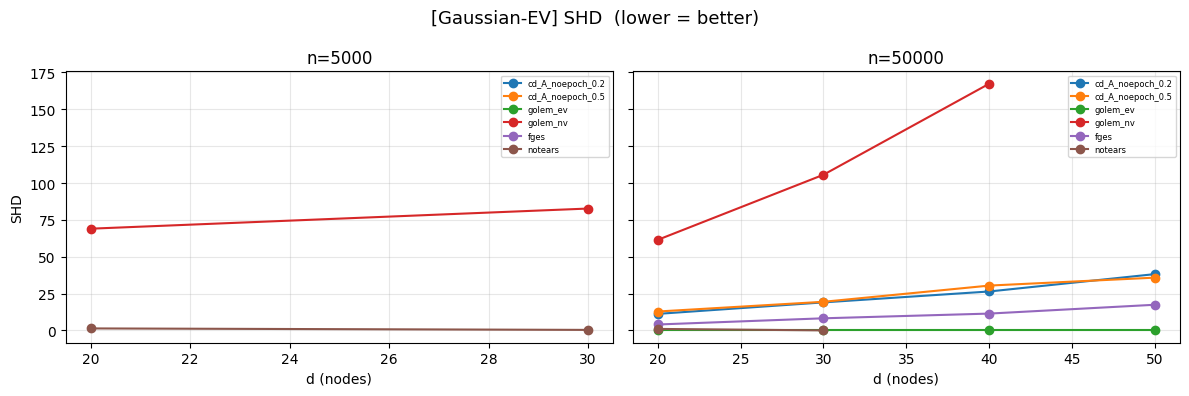

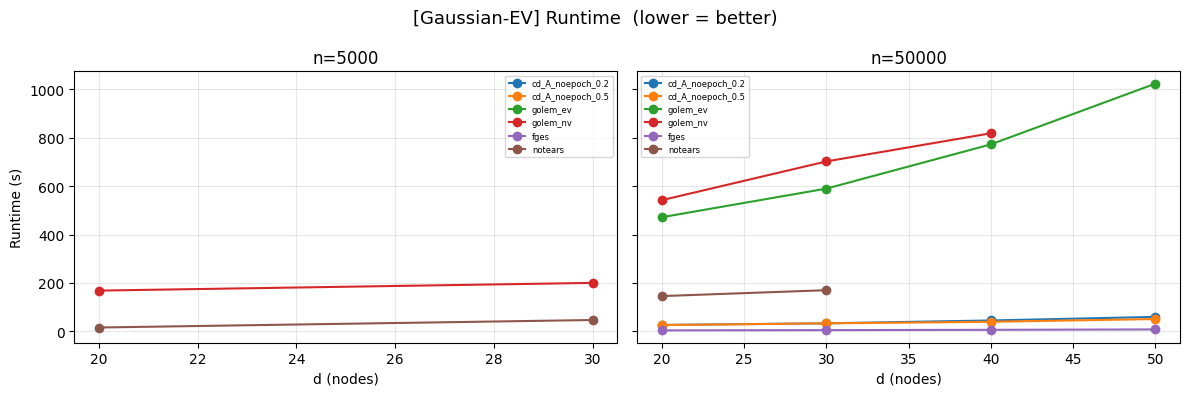

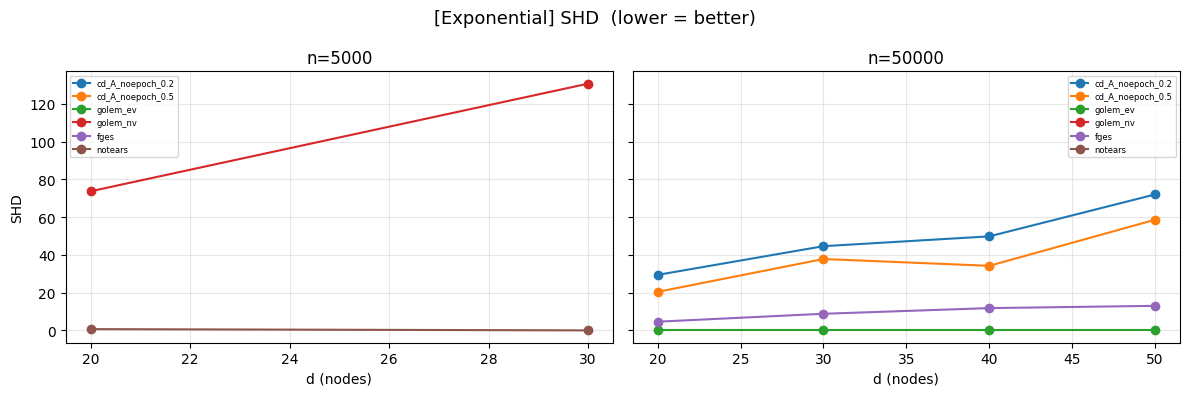

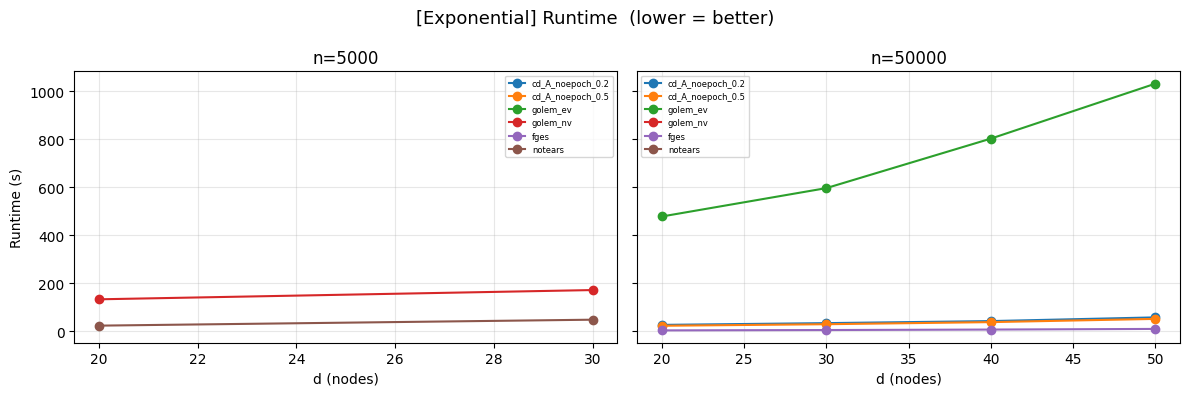

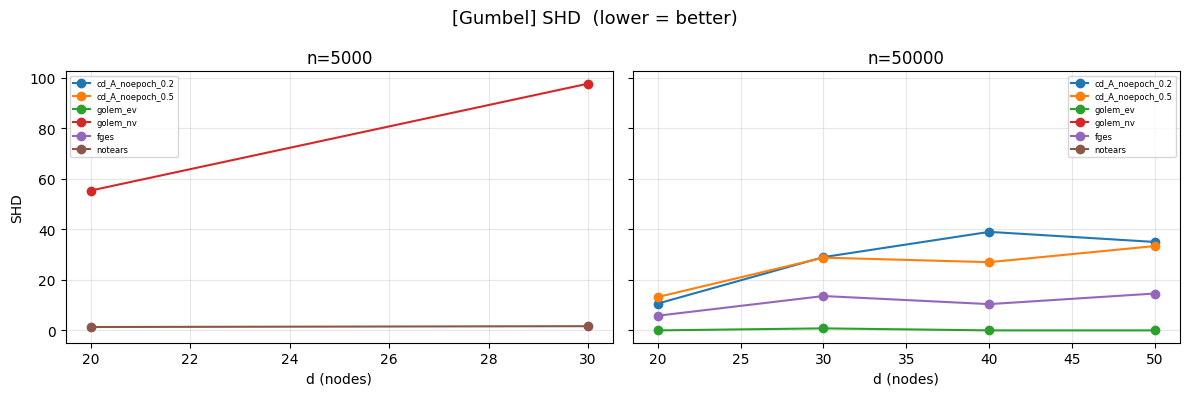

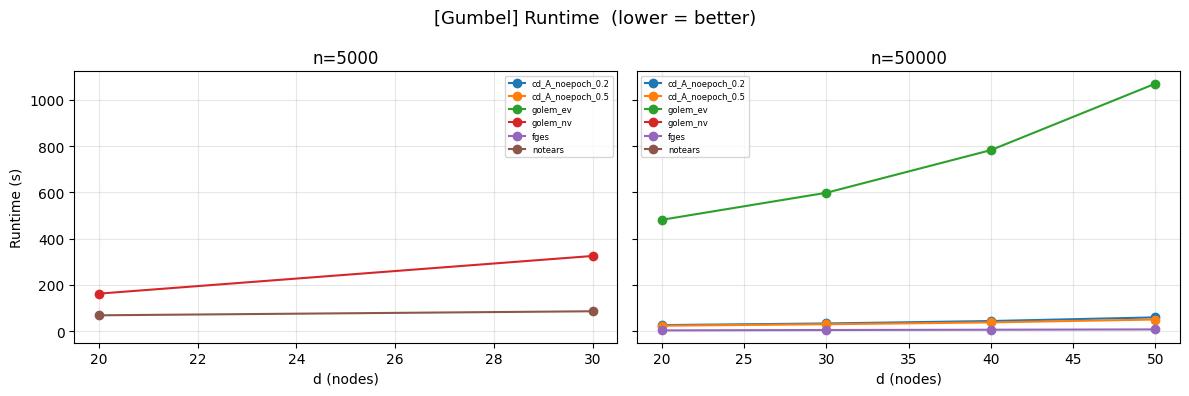

In [22]:
# 13) 可视化：按噪声类型分别绘图
# ──────────────────────────────────────────────────────────────────────────────
# 每种噪声类型生成一组图：MEC match rate / SHD / Runtime vs d

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 11。')
else:
    _algs = [a for a in ALGORITHM_ORDER if a in df_all_trials['algorithm'].unique()]

    for _nt in CFG['noise_types']:
        _sub = df_all_trials[df_all_trials['noise_type'] == _nt]
        if len(_sub) == 0:
            continue

        _n_vals = sorted(_sub['n_samples'].unique())
        _noise_label = NOISE_LABELS[_nt]

        for _metric, _ylabel, _title_suffix in [
            ('shd',         'SHD',            'SHD  (lower = better)'),
            ('runtime_sec', 'Runtime (s)',     'Runtime  (lower = better)'),
        ]:
            fig, axes = plt.subplots(1, len(_n_vals), figsize=(6 * len(_n_vals), 4),
                                     sharey=True, squeeze=False)
            for _ci, _n in enumerate(_n_vals):
                ax   = axes[0][_ci]
                _dat = _sub[_sub['n_samples'] == _n]
                _agg = _dat.groupby(['d', 'algorithm'])[_metric].mean().reset_index()
                for _a in _algs:
                    _vals = _agg[_agg['algorithm'] == _a]
                    ax.plot(_vals['d'], _vals[_metric], marker='o', label=_a)
                ax.set_title(f'n={_n}')
                ax.set_xlabel('d (nodes)')
                if _ci == 0:
                    ax.set_ylabel(_ylabel)
                ax.legend(fontsize=6, loc='best')
                ax.grid(True, alpha=0.3)
            fig.suptitle(f'[{_noise_label}] {_title_suffix}', fontsize=13)
            plt.tight_layout()
            plt.show()

In [ ]:
# 14) 跳过记录分析
# ──────────────────────────────────────────────────────────────────────────────

if _SKIP_LOGS:
    df_skips = pd.DataFrame(_SKIP_LOGS)
    print(f'Total skips: {len(df_skips)}')
    display(df_skips.groupby(['algorithm', 'noise_type'])['reason'].value_counts().rename('count').reset_index())
else:
    print('No skips -- 所有算法在全部 trial 上均成功运行。')